In [1]:
# Momentum strategy on S&P 500 — notebook assembly
# Parameters
START_DATE = "2015-01-02"
END_DATE   = "2025-01-01"
UNIVERSE_ASOF = "2015-01-01"  # point-in-time S&P500 membership anchor
TOP_N = 50
BOTTOM_N = 50

import pandas as pd
import numpy as np

from findata.sp500_composition import get_sp500_composition
from findata.equity_prices import get_equity_prices

# Display versions for reproducibility
import sys
print({
    "python": sys.version.split()[0],
})

{'python': '3.13.11'}


In [ ]:
# 1) Universe: point-in-time S&P 500 tickers
sp500_tickers = get_sp500_composition(UNIVERSE_ASOF, return_dataframe=False)
print(f"Universe size as of {UNIVERSE_ASOF}: {len(sp500_tickers)} tickers")

# Guard: ensure non-empty
aassert_msg = "No S&P 500 tickers returned; check network/cache for findata.sp500_composition"
assert len(sp500_tickers) > 0, aassert_msg

Universe size as of 2015-01-01: 504 tickers


In [6]:
# 2) Fetch daily adjusted Close prices for the universe
# findata.get_equity_prices returns MultiIndex columns (field, ticker)
prices_all = get_equity_prices(
    tickers=sp500_tickers,
    start_date=START_DATE,
    end_date=END_DATE,
    fields=["Close"],
    frequency="1d",
    auto_adjust=True,
)
close = prices_all["Close"].copy()  # wide [dates x tickers]

# Basic cleaning: drop columns entirely NaN and rows with all-NaN
close = close.dropna(axis=1, how="all").dropna(axis=0, how="all")
print(f"Close shape: {close.shape}")

$ADS: possibly delisted; no timezone found
$MNK: possibly delisted; no timezone found
$JWN: possibly delisted; no timezone found
$DISCA: possibly delisted; no timezone found
$DNB: possibly delisted; no timezone found
$BRK.B: possibly delisted; no timezone found
$SWN: possibly delisted; no timezone found
$CBS: possibly delisted; no timezone found
$AGN-201503: possibly delisted; no timezone found
$MON-201806: possibly delisted; no timezone found
$NBL: possibly delisted; no timezone found
$ESV: possibly delisted; no timezone found
$PXD: possibly delisted; no timezone found
$ANTM: possibly delisted; no timezone found
$TMK: possibly delisted; no timezone found
$DISCK: possibly delisted; no timezone found
$WYND: possibly delisted; no timezone found
$SWY-201501: possibly delisted; no timezone found
$KSU: possibly delisted; no timezone found
$SNDK-201605: possibly delisted; no timezone found
$HOT-201609: possibly delisted; no timezone found
$ALTR-201512: possibly delisted; no timezone found
$G

Close shape: (2516, 380)


In [7]:
# 3) Compute simple daily asset returns
asset_returns = close.pct_change().replace([np.inf, -np.inf], np.nan)

# Optional: keep dates where at least some returns are available
asset_returns = asset_returns.dropna(how="all")

# Sanity check
asset_returns.info(verbose=False)
asset_returns.tail(3)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-05 to 2024-12-31
Columns: 380 entries, A to ZTS
dtypes: float64(380)
memory usage: 7.3 MB


/var/folders/jr/prby656n267_0pztcwybgy5r0000gn/T/ipykernel_77528/4243591173.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  asset_returns = close.pct_change().replace([np.inf, -np.inf], np.nan)


Ticker,A,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WYNN,XEL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,-0.002135,-0.013242,-0.006641,-0.002429,-0.011791,-0.008175,-0.004907,-0.000593,-0.003533,-0.008958,...,-0.007054,-0.000587,-0.000094,-0.003158,-0.002181,-0.007935,-0.005662,-0.003543,-0.012105,-0.005558
2024-12-30,-0.008263,-0.013263,-0.010168,-0.019045,-0.010360,-0.001523,-0.020416,-0.010083,-0.010838,-0.000202,...,-0.032138,-0.008072,-0.006762,-0.015311,-0.026229,-0.010636,-0.012645,-0.011535,-0.006584,-0.014338
2024-12-31,0.001252,-0.007058,0.008513,0.002748,-0.001986,-0.002512,-0.000470,0.008987,-0.000819,-0.006588,...,0.003845,-0.001035,0.017114,0.017694,-0.026559,-0.002236,0.004793,0.002182,-0.001289,0.004253


In [8]:
# 4) Momentum signal: z-score of 30-day average returns (cross-sectional per date)
# Compute 30D average of daily returns
avg30 = asset_returns.rolling(window=30, min_periods=20).mean()

# Cross-sectional z-score each date: (x - mean)/std across tickers
cs_mean = avg30.mean(axis=1)
cs_std = avg30.std(axis=1).replace(0.0, np.nan)
signal_z = (avg30.sub(cs_mean, axis=0)).div(cs_std, axis=0)

# Clip extreme z-scores for stability (optional)
signal_z = signal_z.clip(lower=-5, upper=5)

signal_z.tail(3)

Ticker,A,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WYNN,XEL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,0.429989,1.588047,0.771616,0.246111,-0.037210,-1.314722,0.573507,0.169508,-0.005953,-0.140594,...,0.742264,0.241259,-0.917255,1.307524,1.444358,-0.152080,0.365092,0.036983,-0.553719,-0.409206
2024-12-30,0.672004,1.326264,0.733051,0.149744,0.112996,-1.219676,0.424619,-0.018591,0.098777,0.098669,...,-0.400661,0.155301,-0.936499,0.872414,1.051055,-0.051709,0.161642,0.058174,-0.542469,-0.372932
2024-12-31,0.989074,1.544666,1.180490,0.028954,0.288291,-0.975044,0.720198,-0.193620,0.180741,0.229878,...,-0.240995,-0.012836,-0.873192,0.871186,0.780815,-0.191747,0.418203,-0.387685,-0.724659,-0.513128


In [9]:
# 5) Construct daily long-short portfolio: top 50 long, bottom 50 short (equal-weight), dollar neutral

def build_long_short_weights(scores: pd.DataFrame, top_n: int, bottom_n: int) -> pd.DataFrame:
    # For each date, pick top and bottom names by score; ignore NaNs.
    def one_day_weights(row: pd.Series) -> pd.Series:
        s = row.dropna()
        if s.empty:
            return pd.Series(index=row.index, dtype=float)
        # Ranks: highest = long
        longs = s.nlargest(min(top_n, len(s))).index
        shorts = s.nsmallest(min(bottom_n, len(s))).index
        w = pd.Series(0.0, index=row.index)
        if len(longs) > 0:
            w.loc[longs] = +0.5 / len(longs)
        if len(shorts) > 0:
            w.loc[shorts] = -0.5 / len(shorts)
        return w

    weights = scores.apply(one_day_weights, axis=1)
    # Ensure NaNs -> 0
    weights = weights.fillna(0.0)
    # Remove days with no positions
    weights = weights.loc[(weights.abs().sum(axis=1) > 0)]
    return weights

asset_weights_raw = build_long_short_weights(signal_z, TOP_N, BOTTOM_N)
asset_weights_raw.tail(3)

Ticker,A,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WYNN,XEL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,0.00,0.01,0.01,0.0,0.0,-0.01,0.0,0.0,0.0,0.0,...,0.01,0.0,-0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0
2024-12-30,0.01,0.01,0.01,0.0,0.0,-0.01,0.0,0.0,0.0,0.0,...,0.00,0.0,-0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0
2024-12-31,0.01,0.01,0.01,0.0,0.0,-0.01,0.0,0.0,0.0,0.0,...,0.00,0.0,-0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0


In [10]:
# 6) Apply one-day lag to weights to avoid lookahead bias and align with returns
asset_weights = asset_weights_raw.reindex(asset_returns.index).reindex(columns=asset_returns.columns)
asset_weights = asset_weights.shift(1).fillna(0.0)

# Optional: ensure gross exposure = 1.0 where non-zero
gross = asset_weights.abs().sum(axis=1)
scaler = pd.Series(1.0, index=asset_weights.index)
nonzero = gross > 0
scaler.loc[nonzero] = 1.0 / gross.loc[nonzero]
asset_weights = asset_weights.mul(scaler, axis=0)

# Final shapes
print("asset_returns:", asset_returns.shape)
print("asset_weights:", asset_weights.shape)
asset_weights.tail(3)

asset_returns: (2515, 380)
asset_weights: (2515, 380)


Ticker,A,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WYNN,XEL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,0.00,0.01,0.01,0.0,0.0,-0.01,0.0,0.0,0.0,0.0,...,0.01,0.0,-0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0
2024-12-30,0.00,0.01,0.01,0.0,0.0,-0.01,0.0,0.0,0.0,0.0,...,0.01,0.0,-0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0
2024-12-31,0.01,0.01,0.01,0.0,0.0,-0.01,0.0,0.0,0.0,0.0,...,0.00,0.0,-0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0


In [11]:
# 7) Compute daily strategy returns from weights and asset returns (for diagnostics)
strategy_returns = (asset_weights * asset_returns).sum(axis=1)

print("Preview strategy returns:")
strategy_returns.tail(5)

Preview strategy returns:


Date
2024-12-24    0.002696
2024-12-26    0.002490
2024-12-27    0.005985
2024-12-30   -0.002392
2024-12-31   -0.007923
dtype: float64

<Axes: xlabel='Date'>

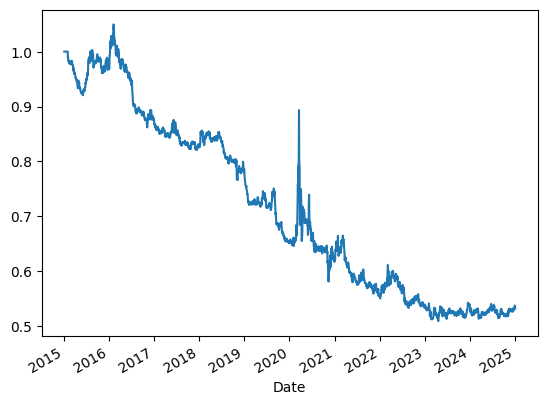

In [14]:
(strategy_returns+1).cumprod().plot()

In [13]:
# 8) Final: call the user-defined backtest function exactly once
# Expecting a function `backtest(asset_returns: pd.DataFrame, asset_weights: pd.DataFrame)` to be defined by the user.
def backtest(asset_returns, asset_weights):
    raise Exception(NotImplementedError)
    
backtest_results = backtest(asset_returns=asset_returns, asset_weights=asset_weights)
backtest_results

Exception: <class 'NotImplementedError'>